# Introduction & Objectifs

## Prédiction de maladies à partir de symptômes binaires

### Objectif
L'objectif de ce projet est de prédire la maladie la plus probable à partir
d'un ensemble de symptômes binaires (présence / absence).

### Type de problème
- Classification multi-classes
- Données médicales
- Symptômes binaires (0 / 1)


In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Diseases_and_Symptoms_dataset.csv')
df = df.copy()

print("Dimensions du dataset :", df.shape)
print("Valeur uniques: ", df['diseases'].nunique())
df.head()

Dimensions du dataset : (96088, 231)
Valeur uniques:  100


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


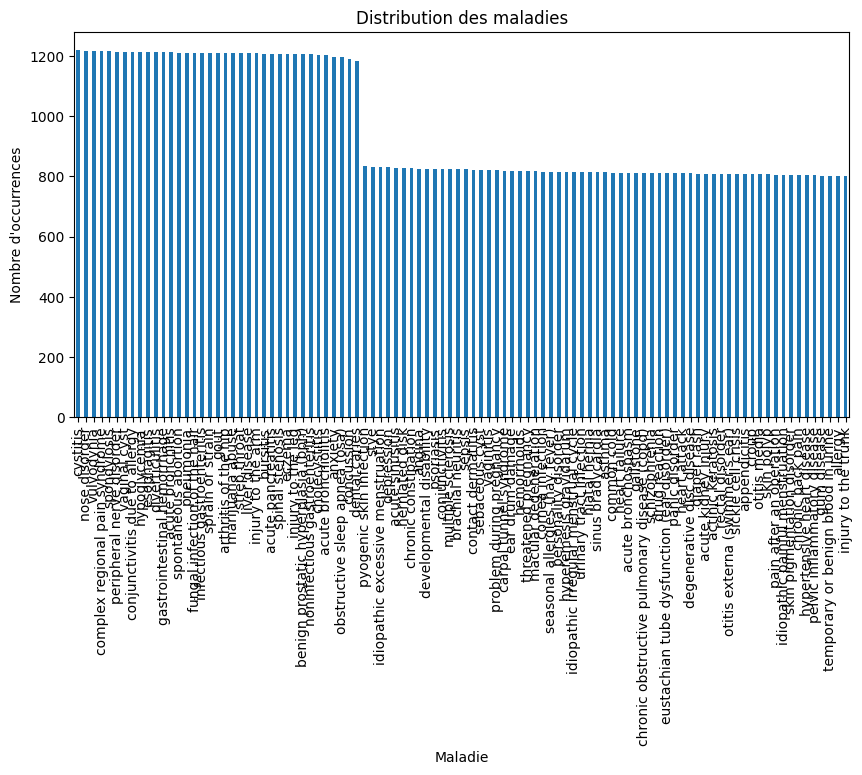

In [30]:
import matplotlib.pyplot as plt

disease_counts = df['diseases'].value_counts()

plt.figure(figsize=(10,5))
disease_counts.plot(kind='bar')
plt.title("Distribution des maladies")
plt.xlabel("Maladie")
plt.ylabel("Nombre d'occurrences")
plt.show()


# PRÉTRAITEMENT DES DONNÉES

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diseases'])
y = df['diseases']


le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# MODÈLES CANDIDATS

| Modèle              | Justification                   |
| ------------------- | ------------------------------- |
| Logistic Regression | Baseline linéaire               |
| Naive Bayes         | Excellent pour données binaires |
| Decision Tree       | Interprétable                   |
| Random Forest       | Robuste                         |
| Voting Classifier   | Combine les forces              |


# DÉFINITION DES MODÈLES

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

In [33]:
# Modèles individuels
model_logistic = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_naive_bayes = BernoulliNB()

model_decision_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

In [34]:
# Modèle d'ensemble

model_voting_hard = VotingClassifier(
    estimators=[
        ('lr', model_logistic),
        ('nb', model_naive_bayes),
        ('dt', model_decision_tree),
        ('rf', model_random_forest)
    ],
    voting='hard'
)

model_voting_soft = VotingClassifier(
    estimators=[
        ('lr', model_logistic),
        ('nb', model_naive_bayes),
        ('dt', model_decision_tree),
        ('rf', model_random_forest)
    ],
    voting='soft'
)


In [37]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "Logistic Regression": model_logistic,
    "Naive Bayes": model_naive_bayes,
    "Decision Tree": model_decision_tree,
    "Random Forest": model_random_forest,
    "Voting Hard": model_voting_hard,
    "Voting Soft": model_voting_soft
}

In [38]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Modèle": name,
        "Accuracy": acc,
        "F1-score": f1
    })


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by="F1-score", ascending=False
)

results_df